# Домашнє завдання: Рекомендаційні системи на реальних даних (Goodbooks-10k)

У цьому завданні Ви реалізуєте сучасні (advanced) архітектури рекомендаційних систем із фінального блоку лекції — але вже **не на іграшкових даних, а на реальному датасеті книжкових рейтингів Goodbooks-10k** (десятки тисяч користувачів, тисячі книг, мільйони оцінок).

Це дасть Вам змогу побачити, як підходи поводяться, коли даних справді багато: чому контентних ознак буває замало, як працює retrieval на тисячах елементів, і чому офлайн-метрики на кшталт Recall@K не такі високі, як хотілося б.

**Архітектури, які Ви зберете:** Vector Space Model, Two-Tower, Concat-based ranking (NCF) та двоетапний пайплайн Retrieval → Ranking.

**Стек:** `numpy`, `pandas`, `scikit-learn`, `torch`. GPU не обов'язковий, але з ним тренування буде швидшим (у Colab: *Runtime → Change runtime type → GPU*).

---

## Про датасет

[Goodbooks-10k](https://www.kaggle.com/datasets/zygmunt/goodbooks-10k) — це ~6 млн оцінок 10 000 найпопулярніших книг від 53 424 користувачів. Складається з кількох файлів:

- `ratings.csv` — оцінки: `user_id, book_id, rating` (1–5);
- `books.csv` — метадані книг: `book_id, goodreads_book_id, authors, title, average_rating, ...`;
- `book_tags.csv` — теги/полиці, які користувачі вішали на книги: `goodreads_book_id, tag_id, count`;
- `tags.csv` — розшифровка тегів: `tag_id, tag_name`.

**Важливий нюанс:** на відміну від навчального прикладу, тут **немає готових жанрів**. Жанри доведеться сконструювати самостійно з користувацьких тегів — а це шумні дані (юзери можуть зазначати що завгодно). Це реалістична задача feature engineering, і ми її розберемо в підготовчій частині.

Ще один нюанс із реальних даних: `book_tags.csv` посилається на `goodreads_book_id`, а `ratings.csv` — на `book_id`. Щоб їх поєднати, потрібен джойн через `books.csv`.


## Крок 0. Завантаження даних

Є три способи дістати дані — оберіть будь-який.

**Спосіб A — Kaggle API (рекомендований).** Завантаження з Kaggle API. Зручно, бо декілька файлів і вони завантажаться всі самостійно. Для цього способу завантажте свій `kaggle.json` (Kaggle → Account → Create New API Token), потім виконайте:
```python
from google.colab import files; files.upload()   # оберіть kaggle.json
```
і розкоментуйте відповідний блок нижче.

**Спосіб B — ручне завантаження.** Завантажте архів з посилання на датасет вище з Kaggle, розпакуйте і покладіть `ratings.csv`, `books.csv`, `book_tags.csv`, `tags.csv` поруч із ноутбуком (або через панель Files у Colab).

**Спосіб C — GitHub-дзеркало (фолбек).** Оригінальний автор виклав файли і на GitHub — код нижче підхопить їх автоматично, якщо локально файлів немає.


In [ ]:
# (Спосіб A) Kaggle API — розкоментуйте, якщо завантажили kaggle.json
# !pip -q install kaggle
# import os, shutil
# os.makedirs("/root/.kaggle", exist_ok=True)
# shutil.move("kaggle.json", "/root/.kaggle/kaggle.json"); os.chmod("/root/.kaggle/kaggle.json", 0o600)
# !kaggle datasets download -d zygmunt/goodbooks-10k --unzip -p .

option A but with env Kaggle API key (not legacy kaggle.json)

In [1]:
! pip install kaggle -q

In [6]:
!mkdir -p ./donwloads
!kaggle datasets download -d zygmunt/goodbooks-10k --unzip -p ./downloads

Dataset URL: https://www.kaggle.com/datasets/zygmunt/goodbooks-10k
License(s): CC-BY-SA-4.0
100%|██████████████████████████████████████| 11.6M/11.6M [00:01<00:00, 6.64MB/s]



> Note: Github version has much more ratings samples (about 6millions) compare to version on kaggle (about 1million).

In [1]:
import os
import numpy as np
import pandas as pd

FOLDER = "./downloads"
GITHUB = "https://raw.githubusercontent.com/zygmuntz/goodbooks-10k/master"
FILES = ["ratings.csv", "books.csv", "book_tags.csv", "tags.csv"]

def load(fname):
    """Спочатку шукаємо файл локально, інакше тягнемо з GitHub-дзеркала."""
    if os.path.exists(f"{FOLDER}/{fname}"):
        return pd.read_csv(f"{FOLDER}/{fname}")
    print(f"{fname} не знайдено локально — завантажую з GitHub...")
    return pd.read_csv(f"{GITHUB}/{fname}")

ratings = load("ratings.csv")
books = load("books.csv")
book_tags = load("book_tags.csv")
tags = load("tags.csv")

print("ratings:", ratings.shape)
print("books:  ", books.shape)
print("book_tags:", book_tags.shape, "| tags:", tags.shape)
books[["book_id", "authors", "title", "average_rating"]].head()

ratings: (981756, 3)
books:   (10000, 23)
book_tags: (999912, 3) | tags: (34252, 2)


,book_id,authors,title,average_rating
0,2767052,Suzanne Collins,"The Hunger Games (The Hunger Games, #1)",4.34
1,3,"J.K. Rowling, Mary GrandPré",Harry Potter and the Sorcerer's Stone (Harry P...,4.44
2,41865,Stephenie Meyer,"Twilight (Twilight, #1)",3.57
3,2657,Harper Lee,To Kill a Mockingbird,4.25
4,4671,F. Scott Fitzgerald,The Great Gatsby,3.89


## Крок 1. Інженерія жанрів із тегів (feature engineering)

Жанрів у датасеті немає, але є користувацькі теги. Виберемо набір канонічних жанрів і для кожної книги позначимо, які з них їй приписали користувачі. Так ми отримаємо **бінарну матрицю book × genre** — це й будуть контентні ознаки айтемів (аналог `movie_feats_df` із лекції, але здобутий з реальних шумних даних).


In [2]:
books.columns

Index(['id', 'book_id', 'best_book_id', 'work_id', 'books_count', 'isbn',
       'isbn13', 'authors', 'original_publication_year', 'original_title',
       'title', 'language_code', 'average_rating', 'ratings_count',
       'work_ratings_count', 'work_text_reviews_count', 'ratings_1',
       'ratings_2', 'ratings_3', 'ratings_4', 'ratings_5', 'image_url',
       'small_image_url'],
      dtype='object')

In [3]:
ratings.head()

,book_id,user_id,rating
0,1,314,5
1,1,439,3
2,1,588,5
3,1,1169,4
4,1,1185,4


In [4]:
ratings["rating"].describe()

count    981756.000000
mean          3.856534
std           0.983941
min           1.000000
25%           3.000000
50%           4.000000
75%           5.000000
max           5.000000
Name: rating, dtype: float64

In [5]:
print("Unique users:", ratings.user_id.nunique())
print("Unique books:", ratings.book_id.nunique())

Unique users: 53424
Unique books: 10000


In [31]:
# List of canonical genres that will be used as content features
GENRES = [
    "fantasy", "romance", "mystery", "thriller", "horror", "historical",
    "science-fiction", "young-adult", "nonfiction", "classics",
    "contemporary", "crime"
]

# Create a mapping: tag name -> tag ID
# Example: "fantasy" -> 8717
name_to_tagid = dict(zip(tags["tag_name"], tags["tag_id"]))

# Keep only the selected genres
genre_tag_ids = {
    g: name_to_tagid[g]
    for g in GENRES
    if g in name_to_tagid
}

# book_tags.csv uses Goodreads book IDs,
# while ratings.csv uses internal book id values.
# Create a mapping between them.
gid_to_bid = dict(zip(books["best_book_id"], books["id"]))

# Reverse mapping: tag ID -> genre name
tagid_to_genre = {
    tid: g
    for g, tid in genre_tag_ids.items()
}

# Keep only rows corresponding to the selected genres
bt = book_tags[
    book_tags["tag_id"].isin(genre_tag_ids.values())
].copy()

# Convert Goodreads book IDs into internal book IDs
bt["book_id"] = bt["goodreads_book_id"].map(gid_to_bid)

# Remove rows that could not be matched
bt = bt.dropna(subset=["book_id"])

# Replace tag IDs with human-readable genre names
bt["genre"] = bt["tag_id"].map(tagid_to_genre)

# Build a binary Book × Genre matrix
# A value of 1 means that at least one user assigned this genre tag to the book.
genre_matrix = (
    bt.pivot_table(
        index="book_id",
        columns="genre",
        values="count",
        aggfunc="sum",
        fill_value=0
    )
    .reindex(columns=GENRES, fill_value=0) > 0
).astype(int)

# Show how many books have at least one of the selected genres
print(
    "Книг із хоча б одним жанром:",
    (genre_matrix.sum(axis=1) > 0).sum(),
    "/",
    len(books)
)

# Show the number of books associated with each genre
print("\nРозподіл жанрів:")
print(genre_matrix.sum().sort_values(ascending=False))

# Display the first rows of the Book × Genre matrix
genre_matrix.head()

Книг із хоча б одним жанром: 9715 / 10000

Розподіл жанрів:
genre
contemporary       5128
fantasy            4179
romance            4119
mystery            3601
young-adult        3555
classics           2737
historical         2484
thriller           2449
science-fiction    2170
crime              2027
nonfiction         1800
horror             1328
dtype: int64


genre,fantasy,romance,mystery,thriller,horror,historical,science-fiction,young-adult,nonfiction,classics,contemporary,crime
book_id,,,,,,,,,,,,
1.0,1,1,0,1,0,0,1,1,0,0,1,0
2.0,1,0,1,0,0,0,0,1,0,1,1,0
3.0,1,0,0,0,1,0,1,1,0,0,1,0
4.0,0,0,1,0,0,1,0,1,0,1,1,1
5.0,0,1,0,0,0,1,0,1,0,1,0,0


In [32]:
tagid_to_genre

{11305: 'fantasy',
 26138: 'romance',
 20939: 'mystery',
 30358: 'thriller',
 14821: 'horror',
 14467: 'historical',
 26837: 'science-fiction',
 33114: 'young-adult',
 21773: 'nonfiction',
 7457: 'classics',
 8055: 'contemporary',
 8517: 'crime'}

In [33]:
print("Mapped books:", bt["book_id"].notna().sum())
print("Unmapped books:", bt["book_id"].isna().sum())

Mapped books: 35577
Unmapped books: 0


In [36]:
genre_matrix.head()

genre,fantasy,romance,mystery,thriller,horror,historical,science-fiction,young-adult,nonfiction,classics,contemporary,crime
book_id,,,,,,,,,,,,
1.0,1,1,0,1,0,0,1,1,0,0,1,0
2.0,1,0,1,0,0,0,0,1,0,1,1,0
3.0,1,0,0,0,1,0,1,1,0,0,1,0
4.0,0,0,1,0,0,1,0,1,0,1,1,1
5.0,0,1,0,0,0,1,0,1,0,1,0,0


## Крок 2. Підвибірка під Colab

6 млн рейтингів — забагато для навчального ноутбука на CPU. Візьмемо **топ-N найпопулярніших книг** і **активних користувачів** (хто поставив ≥ 20 оцінок), а тоді обмежимо число користувачів. Так зберігається щільність взаємодій, а тренування лишається швидким.

> Якщо у Вас GPU або багато часу — сміливо збільшуйте `TOP_BOOKS` та `N_USERS`.

> Note: Github version has much more ratings samples (about 6millions) compare to version on kaggle (about 1million). If you use kaggle version feel free to increase `TOP_BOOKS` and `N_USERS` or even use the full dataset if needed


In [38]:
# Parameters for creating a smaller training subset
TOP_BOOKS = 2000       # Keep only the TOP_BOOKS most frequently rated books
MIN_USER_RATINGS = 25  # Keep users who rated at least this many books
N_USERS = 1000         # Randomly sample at most N_USERS users
LIKE_THRESHOLD = 4     # Ratings >= 4 are treated as positive feedback ("likes")

# Fixed random seed for reproducible sampling
rng = np.random.RandomState(42)

# Select the most popular books based on the number of ratings
top_books = ratings["book_id"].value_counts().head(TOP_BOOKS).index

# Keep only ratings for the selected popular books
r = ratings[ratings["book_id"].isin(top_books)]

# Count how many ratings each user has in the filtered dataset
active = r["user_id"].value_counts()

# Keep only active users with enough interactions
r = r[r["user_id"].isin(active[active >= MIN_USER_RATINGS].index)]

# Randomly sample a subset of users to reduce the dataset size
sample_users = rng.choice(
    r["user_id"].unique(),
    size=min(N_USERS, r["user_id"].nunique()),
    replace=False
)

# Keep only ratings from the sampled users
r = r[r["user_id"].isin(sample_users)].copy()

# Keep only books that have genre features
# (required later for the content-based component)
r = r[r["book_id"].isin(genre_matrix.index)].copy()

# Create sorted lists of unique books and users
items = sorted(r["book_id"].unique())
users = sorted(r["user_id"].unique())

# Align the genre matrix with the selected books
# Missing values are replaced with 0 (genre absent)
genre_matrix_short = genre_matrix.reindex(items).fillna(0).astype(int)

# Display basic statistics of the resulting subset
print(f"Взаємодій: {len(r):,} | користувачів: {len(users):,} | книг: {len(items):,}")

# Density = observed interactions / all possible user-book pairs
print(f"Щільність: {len(r) / (len(users) * len(items)):.4f}")

Взаємодій: 13,859 | користувачів: 476 | книг: 1,750
Щільність: 0.0166


In [40]:
import torch
import torch.nn as nn

# Fix the random seed for reproducible PyTorch results
torch.manual_seed(42)

# Create mappings from original user/book IDs to consecutive integer indices
# Neural networks work with integer indices starting from 0
user_to_idx = {u: i for i, u in enumerate(users)}
item_to_idx = {b: i for i, b in enumerate(items)}

# Mapping from book id to book title, useful later for displaying recommendations
title_of = dict(zip(books["id"], books["title"]))

# Convert the Book × Genre matrix into a PyTorch tensor
# Shape: (number of books, number of genres)
item_feats = torch.tensor(genre_matrix_short.values, dtype=torch.float32)

# Number of items/books in the selected subset
M = len(items)

# Number of genre features per book
n_genres = item_feats.shape[1]

# Shuffle all interactions before splitting into train and validation sets
r = r.sample(frac=1, random_state=42).reset_index(drop=True)

# Use 20% of interactions for validation
n_val = int(len(r) * 0.2)

# First 20% after shuffling become validation data
val_df = r.iloc[:n_val]

# Remaining 80% become training data
train_df = r.iloc[n_val:]

# Keep only positive training interactions
# Here, rating >= LIKE_THRESHOLD means the user liked the book
train_pos = train_df[train_df["rating"] >= LIKE_THRESHOLD]

# Convert user IDs from positive pairs into tensor indices
pos_u = torch.tensor([user_to_idx[u] for u in train_pos["user_id"]])

# Convert book IDs from positive pairs into tensor indices
pos_i = torch.tensor([item_to_idx[b] for b in train_pos["book_id"]])

# Store books each user has already interacted with in the training set
# This is used later to avoid recommending already seen books
# and to avoid sampling seen books as negative examples
from collections import defaultdict

seen_by_user = defaultdict(set)

for u, b in zip(train_df["user_id"], train_df["book_id"]):
    seen_by_user[user_to_idx[u]].add(item_to_idx[b])

# Store positive validation interactions for evaluation
# These are books the user liked in the validation set
val_pos = defaultdict(set)

for row in val_df.itertuples():
    if row.rating >= LIKE_THRESHOLD:
        val_pos[user_to_idx[row.user_id]].add(item_to_idx[row.book_id])

# Show how many positive training examples we have
# and how many users have at least one liked book in validation
print(
    f"Позитивних пар у train: {len(pos_u):,} | "
    f"користувачів з val-лайками: {len(val_pos):,}"
)

Позитивних пар у train: 7,746 | користувачів з val-лайками: 449


## Крок 3. Метрика оцінки якості рангування

В лекції ми з вами для оцінки якості використовували **RMSE**. Це валідний варіант, коли треба швидко оцінити якість рек. моделі, але спрощений. RMSE показує, наскільки точно модель передбачає оцінку, яку користувач поставить елементу.

В реальних системах нас ще цікавить **якість ранжування** — наскільки релевантні елементи потрапили в топ списку, який ми реально показуємо користувачу. Для цього використовують ранжувальні метрики: **Precision@K**, **Recall@K**, **NDCG**, **MAP**, **MRR**.

Детальніше можна познайомитись з цими мериками тут:
- огляд метрик для рекомендаційних систем: https://www.evidentlyai.com/ranking-metrics/evaluating-recommender-systems
- Precision та Recall at K: https://www.evidentlyai.com/ranking-metrics/precision-recall-at-k

Нижче давайте реалізуємо функцію `recall_at_k` і будемо оцінювати нею всі наші моделі.

![](https://cdn.prod.website-files.com/660ef16a9e0687d9cc27474a/662c4327f27ee08d3e4d4b2e_6577812c4d677925f1ab5f84_precision_recall_k9.png)

![](https://cdn.prod.website-files.com/660ef16a9e0687d9cc27474a/662c4327f27ee08d3e4d4b47_657781b1f9c868e0cda088f6_precision_recall_k11.png)

**Як працює `recall_at_k`:**

1. Для кожного користувача ми беремо його реальні вподобання з валідаційної вибірки (`val_pos` — книги, які він оцінив на ≥ 4), просимо модель оцінити всі книги й відбираємо топ-K рекомендацій. Перед цим прибираємо книги, які користувач уже бачив у train (щоб не рекомендувати відоме).

2. Далі рахуємо, скільки книг із топ-K справді потрапили в його вподобання (`hits`), і ділимо на загальну кількість релевантних книг (обмежену K, бо більше за K у топ і не влізе).

3. Усереднюємо по всіх користувачах — і отримуємо одне число від 0 до 1: **яку частку того, що користувачу реально сподобалось, модель змогла підняти в топ-K.**

In [41]:
def recall_at_k(score_fn, k=10):
    """
    Compute Recall@K for a recommender model.

    score_fn(user_idx_tensor) should return a score matrix
    with shape (number_of_users, number_of_books).

    Higher scores mean stronger recommendations.
    """

    # Evaluate only users who have at least one liked book in validation
    eval_users = list(val_pos.keys())

    # hits = number of relevant books found in top-K
    # total = maximum number of relevant books we could find
    hits, total = 0, 0

    # Disable gradient tracking because this is evaluation, not training
    with torch.no_grad():

        # Get recommendation scores for all evaluation users
        # Shape: (len(eval_users), M)
        scores = score_fn(torch.tensor(eval_users))

        # Process each user separately
        for row, u in enumerate(eval_users):

            # Copy scores for this user so we can modify them safely
            s = scores[row].clone()

            # Remove books the user already saw in training
            # We do this by assigning them a very low score
            for i in seen_by_user[u]:
                s[i] = -1e9

            # Select indices of the top-K highest-scoring books
            topk = torch.topk(s, k).indices.tolist()

            # Ground-truth liked books from the validation set
            truth = val_pos[u]

            # Count how many recommended books are actually relevant
            hits += len(set(topk) & truth)

            # Count how many relevant books could possibly be recovered
            # We use min(len(truth), k) because top-K cannot contain more than K items
            total += min(len(truth), k)

    # Avoid division by zero if there are no validation positives
    return hits / max(total, 1)

---
## Завдання 1. Vector Space Model (векторний підхід)

Перетворимо і книги, і користувачів на вектори в спільному просторі та шукатимемо рекомендації через cosine similarity. Роль ембединга книги відіграє її **нормалізований вектор жанрів** (пояснення про нормалізацію - нижче), а вектор користувача збираємо як **average pooling** ембедингів книг, які він уподобав.

**Що зробити:**

1. Побудуйте `item_emb` — матрицю L2-нормалізованих жанрових векторів усіх книг.
2. Реалізуйте функцію `user_vector(user_idx)` — зважене (за оцінкою) середнє ембедингів уподобаних книг користувача.
3. Реалізуйте функцію `vsm_scores(user_idxs)` — оцінки (cosine) усіх книг для набору користувачів, та порахуйте `recall_at_k`.
4. Покажіть топ-5 рекомендацій для одного користувача (з назвами книг).

**Довідка:**

L2-нормалізація — це ділення вектора на його довжину (L2-норму), щоб отримати вектор тієї ж напрямленості, але одиничної довжини.

Норма рахується як корінь із суми квадратів компонент:

$$\|v\|_2 = \sqrt{(v_1^2 + v_2^2 + \dots + v_n^2)}$$

а сам нормалізований вектор — це
$$\hat{v} = \frac{v}{\|v\|_2}$$

Навіщо це в рекомендаційних системах: після нормалізації **косинусна подібність зводиться до простого скалярного добутку**. Бо $\cos(a, b) = \frac{a \cdot b}{\|a\|\|b\|}$, і якщо обидва вектори вже одиничної довжини, знаменник = 1, тож $\cos(a,b) = a \cdot b$. Це і швидше, і прибирає вплив «довжини» вектора — порівнюється лише напрямок (тобто склад жанрів/смаків), а не те, скільки книг користувач оцінив.

*Приклад:*

Вектор `[3, 4]` має довжину $\sqrt{(9+16)}=5$, після нормалізації стає `[0.6, 0.8]` — напрямок той самий, довжина 1.

In [42]:
import torch.nn.functional as F

# 1. Build L2-normalized item embeddings
# Each book is represented by its genre vector.
# After normalization, cosine similarity can be computed as a dot product.
item_emb = F.normalize(item_feats, p=2, dim=1)

print("item_emb shape:", item_emb.shape)

item_emb shape: torch.Size([1750, 12])


In [43]:
item_feats[:3], item_emb[:3]

(tensor([[1., 1., 0., 1., 0., 0., 1., 1., 0., 0., 1., 0.],
         [1., 0., 1., 0., 0., 0., 0., 1., 0., 1., 1., 0.],
         [0., 0., 1., 1., 0., 1., 0., 0., 0., 1., 1., 0.]]),
 tensor([[0.4082, 0.4082, 0.0000, 0.4082, 0.0000, 0.0000, 0.4082, 0.4082, 0.0000,
          0.0000, 0.4082, 0.0000],
         [0.4472, 0.0000, 0.4472, 0.0000, 0.0000, 0.0000, 0.0000, 0.4472, 0.0000,
          0.4472, 0.4472, 0.0000],
         [0.0000, 0.0000, 0.4472, 0.4472, 0.0000, 0.4472, 0.0000, 0.0000, 0.0000,
          0.4472, 0.4472, 0.0000]]))

In [44]:
def user_vector(user_idx):
    """
    Build a user vector as a weighted average of embeddings
    of books the user liked in the training set.

    We use only books with rating >= LIKE_THRESHOLD.
    Ratings are used as weights.
    """

    # Get original user_id from internal index
    original_user_id = users[user_idx]

    # Select this user's positive interactions from train data
    user_likes = train_df[
        (train_df["user_id"] == original_user_id) &
        (train_df["rating"] >= LIKE_THRESHOLD)
    ]

    # If the user has no liked books in train,
    # return a zero vector
    if len(user_likes) == 0:
        return torch.zeros(n_genres)

    # Convert book IDs to item indices
    item_indices = torch.tensor([
        item_to_idx[b]
        for b in user_likes["book_id"]
    ])

    # Use ratings as weights
    weights = torch.tensor(
        user_likes["rating"].values,
        dtype=torch.float32
    )

    # Get embeddings of liked books
    liked_embs = item_emb[item_indices]

    # Weighted average pooling
    user_emb = (liked_embs * weights[:, None]).sum(dim=0) / weights.sum()

    # Normalize user vector as well
    user_emb = F.normalize(user_emb, p=2, dim=0)

    return user_emb

### Recall@10

In [45]:
def vsm_scores(user_idxs):
    """
    Compute cosine similarity scores between users and all books.

    user_idxs: tensor/list of user indices
    returns: matrix of shape (number_of_users, number_of_books)
    """

    # Build user vectors one by one
    user_embs = torch.stack([
        user_vector(int(u))
        for u in user_idxs
    ])

    # Since both user_embs and item_emb are normalized,
    # cosine similarity = dot product
    scores = user_embs @ item_emb.T

    return scores

In [46]:
vsm_recall = recall_at_k(vsm_scores, k=10)

print(f"VSM Recall@10: {vsm_recall:.4f}")

VSM Recall@10: 0.1168


In [47]:
def show_vsm_recommendations(user_idx=None, user_id=None, k=5):
    """
    Show top-k VSM recommendations for one user.

    You can pass either:
    - user_idx: internal index from 0 to len(users)-1
    - user_id: original user_id from the dataset
    """

    if user_id is not None:
        if user_id not in user_to_idx:
            print(f"user_id={user_id} is not in the sampled dataset.")
            return
        user_idx = user_to_idx[user_id]

    if user_idx is None:
        raise ValueError("Pass either user_idx or user_id.")

    if user_idx < 0 or user_idx >= len(users):
        raise ValueError(f"user_idx must be between 0 and {len(users)-1}.")

    with torch.no_grad():
        scores = vsm_scores(torch.tensor([user_idx]))[0]

        scores = scores.clone()
        for i in seen_by_user[user_idx]:
            scores[i] = -1e9

        topk = torch.topk(scores, k).indices.tolist()

    original_user_id = users[user_idx]

    print(f"Top-{k} recommendations for user_id={original_user_id} / user_idx={user_idx}:")

    for rank, item_idx in enumerate(topk, start=1):
        book_id = items[item_idx]
        title = title_of[book_id]
        score = scores[item_idx].item()

        print(f"{rank}. {title} | score={score:.4f}")

### Results Analysis

In [48]:
train_pos.head()

,book_id,user_id,rating
2771,3803,29769,4
2775,4452,10642,4
2777,4867,7913,5
2780,5406,51612,5
2783,4293,8914,5


In [49]:
# check users with most positive feedbacks
train_pos["user_id"].value_counts()[:10]

user_id
34568    41
8861     39
8779     38
45876    36
52895    35
21987    34
8914     33
5345     32
37582    32
12707    31
Name: count, dtype: int64

In [58]:
# ids and indeces of 3 users from top 10 above
users.index(34568), users.index(8861), users.index(8779)

(338, 82, 78)

In [54]:
# show recommnedataions for above 3 based on weighted avarage user vectors similarity with books
show_vsm_recommendations(user_idx=338, k=5)
print('\n')
show_vsm_recommendations(user_idx=82, k=5)
print('\n')
show_vsm_recommendations(user_id=8779, k=5)
print('\n')

Top-5 recommendations for user_id=34568 / user_idx=338:
1. Pale Demon (The Hollows, #9) | score=0.9127
2. Dime Store Magic (Women of the Otherworld, #3) | score=0.9127
3. The Lust Lizard of Melancholy Cove (Pine Cove, #2) | score=0.9127
4. A Caress of Twilight (Merry Gentry, #2) | score=0.8982
5. Undead and Unemployed (Undead, #2) | score=0.8982


Top-5 recommendations for user_id=8861 / user_idx=82:
1. The Oath | score=0.9701
2. Sandman Slim (Sandman Slim, #1) | score=0.9701
3. Patient Zero (Joe Ledger, #1) | score=0.9701
4. Still Life With Crows (Pendergast, #4) | score=0.9701
5. Ice Station (Shane Schofield, #1) | score=0.9701


Top-5 recommendations for user_id=8779 / user_idx=78:
1. Allies of the Night (Cirque du Freak, #8) | score=0.9406
2. Night Watch (Watch #1) | score=0.9406
3. Hunters of the Dusk (Cirque Du Freak, #7) | score=0.9406
4. Vampire Mountain (Cirque Du Freak, #4) | score=0.9406
5. The Retribution of Mara Dyer (Mara Dyer, #3) | score=0.9235




### Results Analysis & Visualizations

For better understanding the results meaning try to visualize something

In [55]:
# helper code
import matplotlib.pyplot as plt

def get_user_genre_profile(item_indices):
    """
    Compute average genre profile for a list of item indices.
    Returns one value per genre.
    """

    if len(item_indices) == 0:
        return np.zeros(n_genres)

    return genre_matrix_short.iloc[item_indices].mean(axis=0).values


def liked_train_items(user_idx):
    """
    Return item indices of books the user liked in train.
    """

    original_user_id = users[user_idx]

    liked = train_df[
        (train_df["user_id"] == original_user_id) &
        (train_df["rating"] >= LIKE_THRESHOLD)
    ]

    return [
        item_to_idx[b]
        for b in liked["book_id"]
        if b in item_to_idx
    ]


def liked_val_items(user_idx):
    """
    Return item indices of books the user liked in validation.
    """

    return list(val_pos.get(user_idx, []))


def recommended_items_vsm(user_idx, k=5):
    """
    Return top-k recommended item indices from the VSM model.
    """

    with torch.no_grad():
        scores = vsm_scores(torch.tensor([user_idx]))[0].clone()

        # Remove books already seen in train
        for i in seen_by_user[user_idx]:
            scores[i] = -1e9

        return torch.topk(scores, k).indices.tolist()

In [56]:
# function to compare genres:
def plot_user_genre_comparison(user_idx, k=5):
    """
    Compare genres from:
    1. Books liked in train
    2. VSM recommendations
    3. Books liked in validation
    """

    train_items = liked_train_items(user_idx)
    rec_items = recommended_items_vsm(user_idx, k=k)
    val_items = liked_val_items(user_idx)

    train_profile = get_user_genre_profile(train_items)
    rec_profile = get_user_genre_profile(rec_items)
    val_profile = get_user_genre_profile(val_items)

    comparison = pd.DataFrame({
        "genre": genre_matrix.columns,
        "liked_train": train_profile,
        "recommended": rec_profile,
        "liked_validation": val_profile
    })

    comparison = comparison.sort_values("liked_train", ascending=False)

    ax = comparison.plot(
        x="genre",
        y=["liked_train", "recommended", "liked_validation"],
        kind="bar",
        figsize=(12, 5)
    )

    ax.set_title(f"Genre profile comparison for user_idx={user_idx}")
    ax.set_ylabel("Average genre value")
    ax.set_xlabel("Genre")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

    return comparison

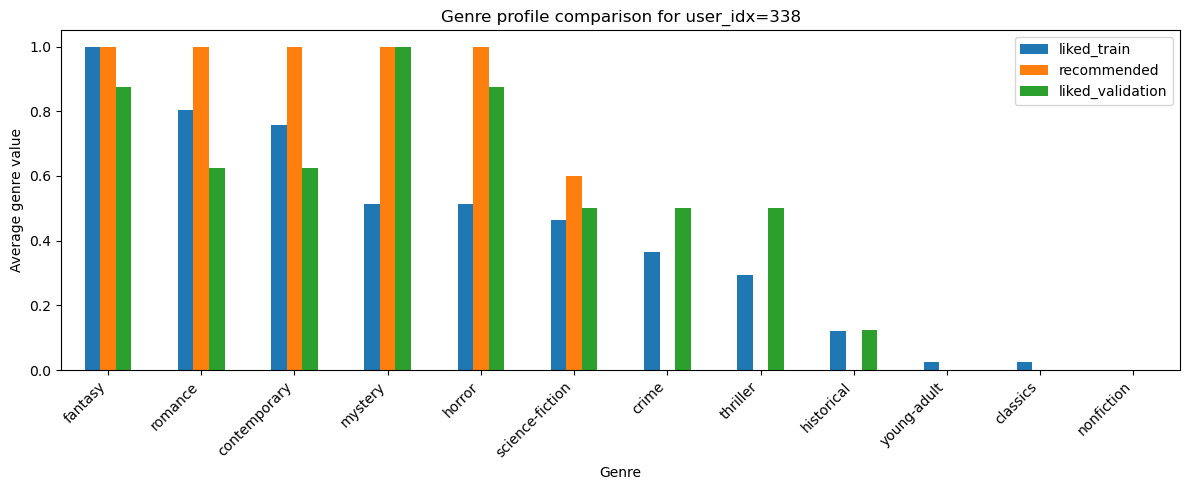

,genre,liked_train,recommended,liked_validation
0,fantasy,1.000000,1.0,0.875
1,romance,0.804878,1.0,0.625
10,contemporary,0.756098,1.0,0.625
2,mystery,0.512195,1.0,1.000
4,horror,0.512195,1.0,0.875
6,science-fiction,0.463415,0.6,0.500
11,crime,0.365854,0.0,0.500
3,thriller,0.292683,0.0,0.500
5,historical,0.121951,0.0,0.125
7,young-adult,0.024390,0.0,0.000


In [57]:
comparison = plot_user_genre_comparison(user_idx=338, k=5)
comparison

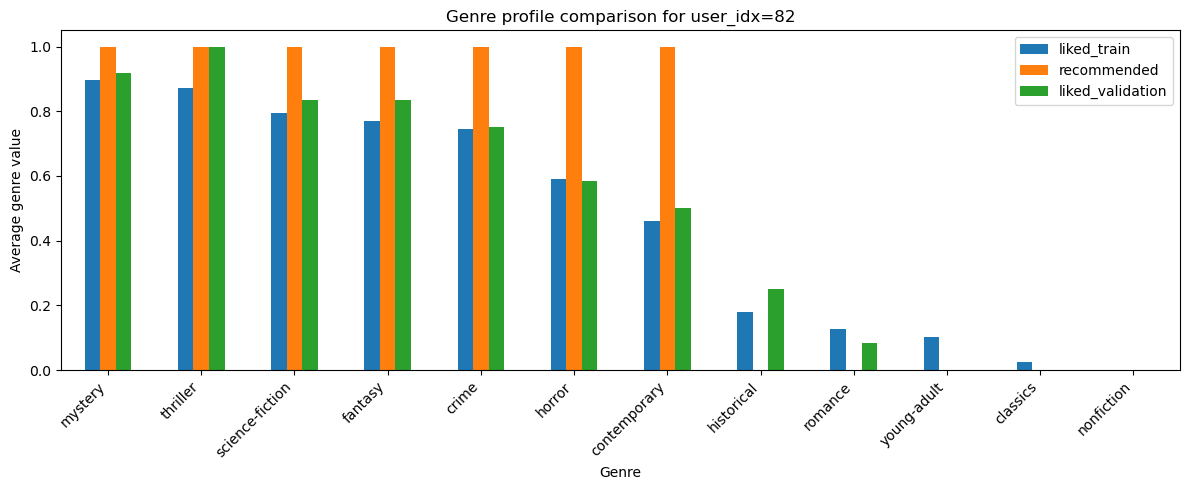

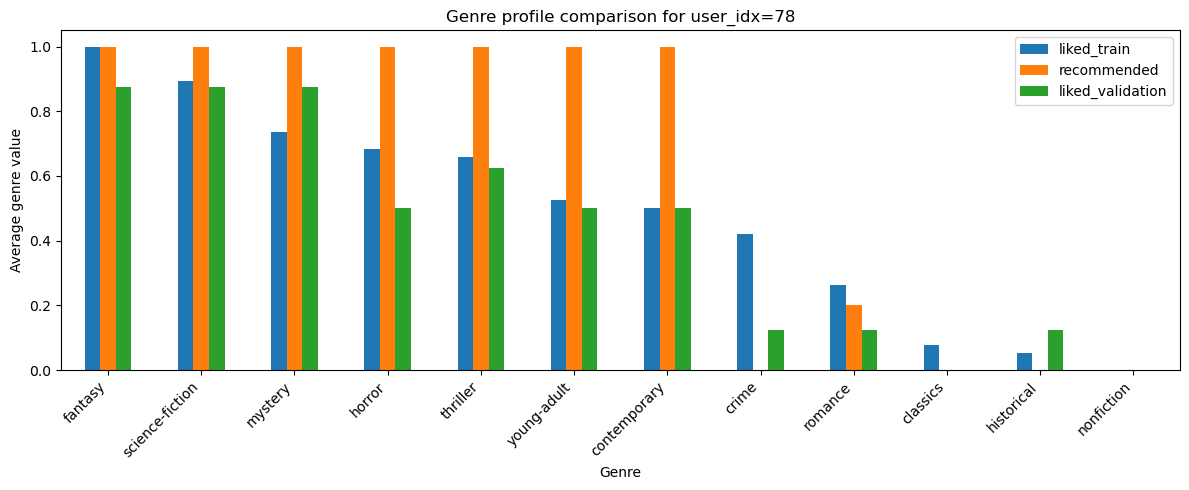

In [59]:
plot_user_genre_comparison(user_idx=82, k=5)
plot_user_genre_comparison(user_idx=78, k=5);

In [60]:
def show_user_books_and_recommendations(user_idx, k=5):
    """
    Show books liked in train, VSM recommendations,
    and liked validation books for one user.
    """

    train_items = liked_train_items(user_idx)
    rec_items = recommended_items_vsm(user_idx, k=k)
    val_items = liked_val_items(user_idx)

    print(f"User: user_id={users[user_idx]} / user_idx={user_idx}")

    print("\nLiked books in train:")
    for i in train_items[:10]:
        book_id = items[i]
        print("-", title_of[book_id])

    print(f"\nTop-{k} VSM recommendations:")
    for i in rec_items:
        book_id = items[i]
        print("-", title_of[book_id])

    print("\nLiked books in validation:")
    for i in val_items:
        book_id = items[i]
        print("-", title_of[book_id])

try to find some user examples with validation data:

In [61]:
list(val_pos.keys())[:10]

[89, 77, 286, 359, 209, 305, 86, 71, 317, 405]

User: user_id=19184 / user_idx=209

Liked books in train:
- The Red Badge of Courage and Selected Short Fiction  
- The Wheel of Darkness (Pendergast, #8)
- Brimstone (Pendergast, #5; Diogenes, #1)
- Twilight Eyes
- The Sea Wolf
- The Defector (Gabriel Allon, #9)
- Ben-Hur: A Tale of the Christ
- Sail
- Portrait of a Spy (Gabriel Allon, #11)
- Cradle and All

Top-5 VSM recommendations:
- Tick Tock
- The Good Guy
- Cold Fire
- The Boys from Brazil
- Sandman Slim (Sandman Slim, #1)

Liked books in validation:
- The Messenger (Gabriel Allon, #6)
- The Darkest Evening of the Year
- The Face
- Tick Tock
- Darkness


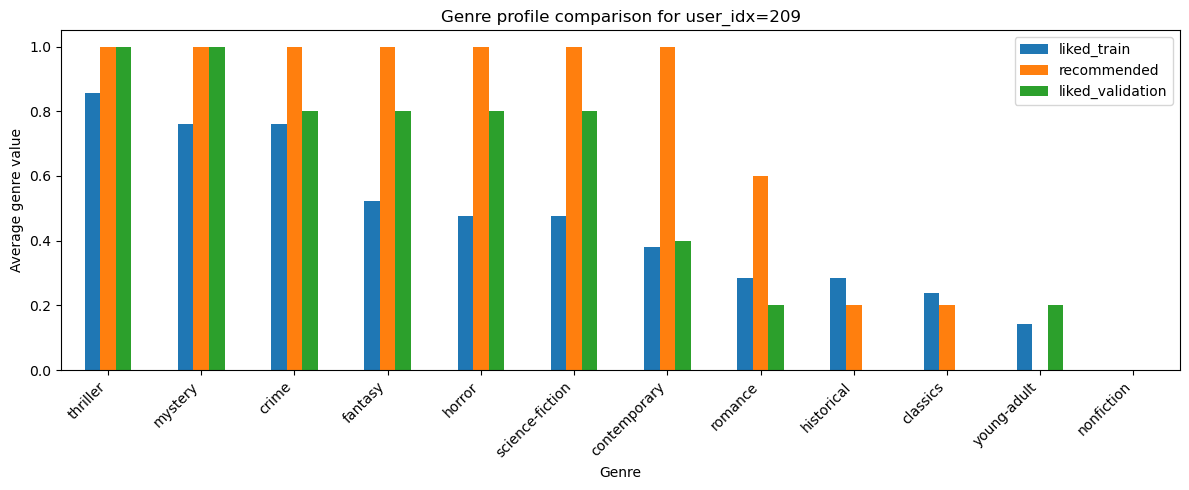

In [62]:
show_user_books_and_recommendations(user_idx=209, k=5)
plot_user_genre_comparison(user_idx=209, k=5);

User: user_id=9214 / user_idx=86

Liked books in train:
- Seize the Night (Moonlight Bay, #2)
- Angels Flight (Harry Bosch, #6; Harry Bosch Universe, #7)
- Hideaway
- High Noon
- Lifeguard
- The Funhouse
- Whispers
- The Darkest Evening of the Year
- Midnight
- Run for Your Life (Michael Bennett, #2)

Top-5 VSM recommendations:
- From the Corner of His Eye
- Chew, Vol. 1: Taster's Choice
- Micro
- Brimstone (Pendergast, #5; Diogenes, #1)
- The Bad Place

Liked books in validation:
- From the Corner of His Eye
- Cradle and All
- Lifeguard
- Chasing the Dime
- The Key to Midnight
- The Vision
- City of Bones (Harry Bosch, #8; Harry Bosch Universe, #10)
- The Face
- The Bad Place


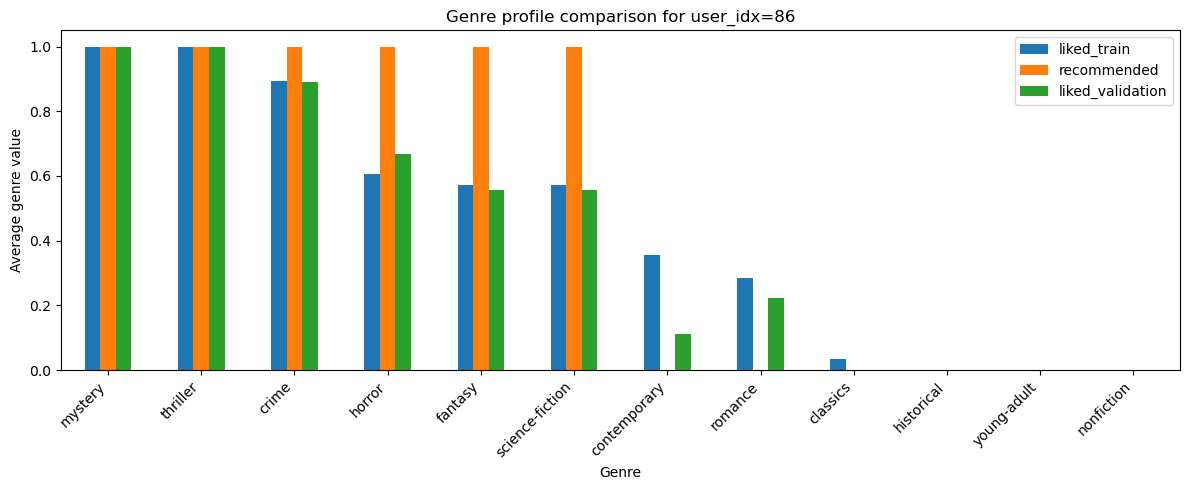

In [66]:
show_user_books_and_recommendations(user_idx=86, k=5)
plot_user_genre_comparison(user_idx=86, k=5);

**Питання:** Recall@10 у векторного підходу досить низький. Чому?


**Answer:**

Recall@10 is low because the Vector Space Model uses only simple genre-based content features. Genres are coarse and many books share the same or very similar genre vectors, so the model cannot distinguish between books with the same genre composition. It also does not use collaborative filtering signals, such as which books are liked by similar users. Therefore, the model can capture broad user preferences, but it is weak at ranking the exact relevant books into the top-10 list. A score of 0.1168 is expected for such a simple baseline and can be improved by adding more content features, popularity signals, or collaborative embeddings.

---
## Завдання 2. Two-Tower архітектура

У Завданні 1 вектор користувача рахувався «вручну». Two-Tower натомість **навчає дві окремі башти**: User Tower (з ембединга user_id) та Item Tower (з жанрових ознак). Мережа зводить вектори уподобаних пар близько, а випадкових — далеко. Перевага: вектори книг рахуються один раз і кладуться в індекс (наприклад, FAISS) для швидкого retrieval — рахувати в реальному часі треба лише вектор користувача. Це **late fusion**.

**Що зробити:**

1. Реалізуйте `TwoTower` (user_tower через `nn.Embedding`, item_tower зі жанрових ознак), виходи L2-нормалізуйте.
2. Навчіть на лайках як позитивах і **negative sampling з усього корпусу** (як у пейпері від YouTube) з `BCEWithLogitsLoss` - він є реалізований в PyTorch.
3. Порахуйте `recall_at_k` через попередньо обчислені вектори книг і покажіть приклад рекомендацій.

> **Підказка.** Множте логіти на «температуру» (\~10), бо скалярний добуток нормалізованих векторів лежить у [-1, 1].
> Множення на температуру (\~10) розтягує діапазон логітів до [-10, 10], і тоді сигмоїда може видавати по-справжньому впевнені ймовірності (близькі до 0 і 1). Це дає лосу нормальний градієнт і модель навчається.


### TwoTower Model


In [67]:
# Model
import torch
import torch.nn as nn
import torch.nn.functional as F

class TwoTower(nn.Module):
    def __init__(self, n_users, n_genres, emb_dim=32, hidden_dim=64, temperature=10.0):
        super().__init__()

        self.temperature = temperature

        # User Tower: learns an embedding for each user_id
        self.user_tower = nn.Embedding(n_users, emb_dim)

        # Item Tower: transforms genre features into an item embedding
        self.item_tower = nn.Sequential(
            nn.Linear(n_genres, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, emb_dim)
        )

    def user_emb(self, user_idx):
        # User vector from embedding table
        u = self.user_tower(user_idx)

        # L2-normalize so dot product becomes cosine similarity
        return F.normalize(u, p=2, dim=1)

    def item_emb(self, item_features):
        # Item vector from genre features
        i = self.item_tower(item_features)

        # L2-normalize item vectors too
        return F.normalize(i, p=2, dim=1)

    def forward(self, user_idx, item_features):
        # Encode users and items
        u = self.user_emb(user_idx)
        i = self.item_emb(item_features)

        # Dot product of normalized vectors = cosine similarity
        logits = (u * i).sum(dim=1)

        # Scale logits to improve BCE learning
        return logits * self.temperature

### Training with negative sampling

In [79]:
# Training with negative sampling
torch.manual_seed(42)

model = TwoTower(
    n_users=len(users),
    n_genres=n_genres,
    emb_dim=64,
    hidden_dim=128,
    temperature=10.0
)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.BCEWithLogitsLoss()

BATCH_SIZE = 24
EPOCHS = 300
NEG_PER_POS = 8

In [80]:
def sample_negatives(user_batch, n_neg=1):
    """
    Sample random negative items for each user.

    We avoid books the user has already seen in train.
    """

    neg_items = []

    for u in user_batch.tolist():
        user_negs = []

        while len(user_negs) < n_neg:
            j = np.random.randint(0, M)

            # Do not use books already seen by the user as negatives
            if j not in seen_by_user[u]:
                user_negs.append(j)

        neg_items.extend(user_negs)

    return torch.tensor(neg_items, dtype=torch.long)

In [81]:
for epoch in range(EPOCHS):
    model.train()

    # Shuffle positive pairs
    perm = torch.randperm(len(pos_u))
    total_loss = 0

    for start in range(0, len(pos_u), BATCH_SIZE):
        idx = perm[start:start + BATCH_SIZE]

        # Positive user-item pairs
        batch_u_pos = pos_u[idx]
        batch_i_pos = pos_i[idx]

        # Negative items sampled for the same users
        batch_i_neg = sample_negatives(batch_u_pos, n_neg=NEG_PER_POS)

        # Repeat users if we sample more than one negative per positive
        batch_u_neg = batch_u_pos.repeat_interleave(NEG_PER_POS)

        # Combine positives and negatives into one batch
        batch_u = torch.cat([batch_u_pos, batch_u_neg])
        batch_i = torch.cat([batch_i_pos, batch_i_neg])

        # Labels: 1 for liked books, 0 for sampled negatives
        y = torch.cat([
            torch.ones(len(batch_u_pos)),
            torch.zeros(len(batch_u_neg))
        ])

        # Get genre features for selected books
        batch_item_feats = item_feats[batch_i]

        # Forward pass
        logits = model(batch_u, batch_item_feats)

        # BCE loss on positive and negative pairs
        loss = loss_fn(logits, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * len(batch_u)

    avg_loss = total_loss / (len(pos_u) * (1 + NEG_PER_POS))

    if ((epoch + 1) % 20 == 0):
        print(f"Epoch {epoch + 1:02d} | loss = {avg_loss:.4f}")

Epoch 20 | loss = 0.2065
Epoch 40 | loss = 0.1730
Epoch 60 | loss = 0.1582
Epoch 80 | loss = 0.1520
Epoch 100 | loss = 0.1478
Epoch 120 | loss = 0.1435
Epoch 140 | loss = 0.1435
Epoch 160 | loss = 0.1425
Epoch 180 | loss = 0.1401
Epoch 200 | loss = 0.1403
Epoch 220 | loss = 0.1399
Epoch 240 | loss = 0.1372
Epoch 260 | loss = 0.1378
Epoch 280 | loss = 0.1390
Epoch 300 | loss = 0.1375


### Recall@10

In [82]:
def two_tower_scores(user_idxs):
    """
    Compute scores for all books for a batch of users.

    Returns a matrix of shape:
    (number_of_users, number_of_items)
    """

    model.eval()

    with torch.no_grad():
        user_idxs = user_idxs.long()

        # Compute user embeddings
        u = model.user_emb(user_idxs)

        # Precompute all item embeddings
        item_vecs = model.item_emb(item_feats)

        # Cosine similarities for all user-item pairs
        scores = u @ item_vecs.T

    return scores

In [83]:
tt_recall = recall_at_k(two_tower_scores, k=10)

print(f"Two-Tower Recall@10: {tt_recall:.4f}")

Two-Tower Recall@10: 0.1973


### Understanding Result and vectors 

In [84]:
item_feats[torch.tensor(0)]

tensor([1., 1., 0., 1., 0., 0., 1., 1., 0., 0., 1., 0.])

In [85]:
model.eval()

with torch.no_grad():
    print(model.user_emb(torch.tensor([416])))              # user vector
    print(model.item_emb(item_feats[torch.tensor([0])]))    # item vector

tensor([[-0.0410,  0.3061, -0.0314,  0.1076, -0.0853,  0.1059,  0.0297, -0.1076,
          0.0416,  0.1026,  0.0541, -0.0060, -0.1419, -0.0113, -0.0707, -0.1056,
         -0.1151,  0.0076,  0.2159, -0.1292,  0.1943,  0.0185,  0.0947,  0.1487,
          0.1519,  0.2012, -0.2239, -0.0208, -0.0390, -0.0355, -0.1372, -0.1562,
         -0.1066, -0.0394,  0.0865,  0.0409, -0.0437,  0.2898,  0.0293, -0.1658,
          0.1197, -0.0219, -0.1971, -0.2033, -0.0882,  0.0356, -0.1904,  0.0376,
          0.1445,  0.0753, -0.1423, -0.0483,  0.2097,  0.0938, -0.0330, -0.2100,
          0.0711,  0.0055,  0.1765, -0.0689,  0.0787,  0.1181,  0.0498, -0.1216]])
tensor([[-0.0652, -0.0775, -0.1264, -0.1709, -0.0047, -0.0579,  0.1518,  0.1027,
         -0.0556,  0.0364, -0.0564,  0.1330, -0.1770, -0.1846,  0.0144,  0.0821,
          0.2046,  0.1876, -0.1740,  0.0278, -0.1203,  0.1176, -0.0691, -0.1555,
         -0.2013, -0.0277,  0.2854,  0.1845, -0.0133,  0.0439,  0.1584,  0.0717,
         -0.0301,  0.1437,

In [86]:
# helper functions

def book_genres(item_idx):
    """
    Return active genres for a book by item index.
    """

    genres = genre_matrix.iloc[item_idx]
    active_genres = genres[genres == 1].index.tolist()

    return ", ".join(active_genres) if active_genres else "no selected genres"

In [87]:
def compare_users_items(user_idxs, item_idxs):
    """
    Compare selected user embeddings with selected item embeddings.

    Returns a DataFrame where rows are users and columns are books.
    Values are cosine similarities.
    """

    model.eval()

    with torch.no_grad():
        user_idxs_t = torch.tensor(user_idxs, dtype=torch.long)
        item_idxs_t = torch.tensor(item_idxs, dtype=torch.long)

        # User vectors: shape (n_users_selected, emb_dim)
        u_emb = model.user_emb(user_idxs_t)

        # Item vectors: shape (n_items_selected, emb_dim)
        i_emb = model.item_emb(item_feats[item_idxs_t])

        # Cosine similarity because both vectors are L2-normalized
        sims = u_emb @ i_emb.T

    row_names = [
        f"user_idx={u} / user_id={users[u]}"
        for u in user_idxs
    ]

    col_names = [
        f"item_idx={i} / {title_of[items[i]]}"
        for i in item_idxs
    ]

    return pd.DataFrame(
        list(sims),
        index=row_names,
        columns=col_names
    )

In [88]:
def show_items_info(item_idxs):
    for i in item_idxs:
        book_id = items[i]
        print(f"item_idx={i} | book_id={book_id} | {title_of[book_id]}")
        print("genres:", book_genres(i))
        print()

In [89]:
show_items_info([0, 10, 25, 100])

item_idx=0 | book_id=1 | The Hunger Games (The Hunger Games, #1)
genres: fantasy, romance, thriller, science-fiction, young-adult, contemporary

item_idx=10 | book_id=3786 | Protect and Defend (Mitch Rapp, #10)
genres: historical, young-adult, classics, contemporary

item_idx=25 | book_id=3801 | 10th Anniversary (Women's Murder Club, #10)
genres: fantasy, romance, mystery, thriller, historical, science-fiction, classics, contemporary

item_idx=100 | book_id=3898 | The Hare With Amber Eyes: A Family's Century of Art and Loss
genres: romance, classics, contemporary



In [90]:
compare_users_items(
    user_idxs=[41, 432, 407, 416, 192],
    item_idxs=[0, 10, 25, 100]
).style\
 .format("{:.3f}")\
 .background_gradient(cmap="Blues", axis=None)

,"item_idx=0 / The Hunger Games (The Hunger Games, #1)","item_idx=10 / Protect and Defend (Mitch Rapp, #10)","item_idx=25 / 10th Anniversary (Women's Murder Club, #10)",item_idx=100 / The Hare With Amber Eyes: A Family's Century of Art and Loss
user_idx=41 / user_id=6042,-0.268,-0.319,-0.394,-0.313
user_idx=432 / user_id=48643,-0.487,-0.403,-0.114,-0.487
user_idx=407 / user_id=44723,-0.566,0.039,-0.333,-0.424
user_idx=416 / user_id=46381,-0.451,-0.365,-0.007,-0.535
user_idx=192 / user_id=16886,-0.410,-0.234,-0.269,-0.250


In [91]:
model.eval()

with torch.no_grad():
    u = model.user_emb(torch.arange(len(users)))
    i = model.item_emb(item_feats)

    scores = (u @ i.T)

print(scores.min().item())
print(scores.max().item())
print(scores.mean().item())

-0.7419100999832153
0.2938484251499176
-0.3517840504646301


The learned embedding space has cosine similarities ranging from approximately -0.74 to 0.29, with an average around -0.35. This is expected because the model is trained with negative sampling, where most user-book pairs are treated as non-relevant. As a result, random pairs are pushed toward negative similarity, while relevant pairs receive higher scores. In retrieval models, the relative ranking of items is more important than the absolute similarity values.

### Show recommendations & Result Analysis

In [92]:
def show_two_tower_recommendations(user_idx=None, user_id=None, k=5):
    """
    Show top-k Two-Tower recommendations for one user.

    Also shows:
    - genres of each recommended book
    - validation books liked by the user, if any
    """

    if user_id is not None:
        if user_id not in user_to_idx:
            print(f"user_id={user_id} is not in the sampled dataset.")
            return
        user_idx = user_to_idx[user_id]

    if user_idx is None:
        raise ValueError("Pass either user_idx or user_id.")

    if user_idx < 0 or user_idx >= len(users):
        raise ValueError(f"user_idx must be between 0 and {len(users)-1}.")

    model.eval()

    with torch.no_grad():
        scores = two_tower_scores(torch.tensor([user_idx]))[0].clone()

        # Do not recommend already seen training books
        for i in seen_by_user[user_idx]:
            scores[i] = -1e9

        topk = torch.topk(scores, k).indices.tolist()

    print(f"Top-{k} Two-Tower recommendations for user_id={users[user_idx]} / user_idx={user_idx}:")

    for rank, item_idx in enumerate(topk, start=1):
        book_id = items[item_idx]
        title = title_of[book_id]
        score = scores[item_idx].item()
        genres = book_genres(item_idx)

        print(f"{rank}. {title} | score={score:.4f} | genres: {genres}")

    # Validation liked books
    validation_items = list(val_pos.get(user_idx, []))

    print("\nValidation liked books:")

    if len(validation_items) == 0:
        print("No liked books in validation for this user.")
    else:
        for rank, item_idx in enumerate(validation_items, start=1):
            book_id = items[item_idx]
            title = title_of[book_id]
            genres = book_genres(item_idx)

            print(f"{rank}. {title} | genres: {genres}")

In [256]:
# check what's in validataion set
# val_pos

In [93]:
show_two_tower_recommendations(user_idx=416, k=10)

Top-10 Two-Tower recommendations for user_id=46381 / user_idx=416:
1. The Doomsday Conspiracy | score=0.2546 | genres: fantasy, mystery, thriller, horror, science-fiction, contemporary
2. Immortal in Death (In Death, #3) | score=0.2546 | genres: nonfiction, contemporary
3. Born in Death (In Death, #23) | score=0.2139 | genres: fantasy, science-fiction, young-adult, classics
4. The Rule of Four | score=0.0020 | genres: fantasy, romance, mystery, historical, science-fiction, young-adult
5. Three Fates | score=0.0020 | genres: historical, young-adult, nonfiction, classics
6. Now You See Her | score=-0.0074 | genres: romance, historical, young-adult, classics, contemporary
7. The Killing Game (Eve Duncan, #2) | score=-0.0074 | genres: romance, young-adult, contemporary
8. 11th Hour (Women's Murder Club, #11) | score=-0.0074 | genres: fantasy, thriller, horror, science-fiction, young-adult, contemporary
9. 10th Anniversary (Women's Murder Club, #10) | score=-0.0074 | genres: fantasy, romanc

* "Immortal in Death (In Death, #3)", "Born in Death (In Death, #23)" from validataion is in recommendations
* there are a lot of genres match here

In [94]:
show_two_tower_recommendations(user_idx=82, k=10)

Top-10 Two-Tower recommendations for user_id=8861 / user_idx=82:
1. Fever Dream (Pendergast, #10) | score=0.2434 | genres: historical, nonfiction
2. Micro | score=0.2126 | genres: fantasy, romance, mystery, thriller, young-adult, contemporary, crime
3. Chew, Vol. 1: Taster's Choice | score=0.2126 | genres: romance, young-adult, contemporary
4. The Face | score=0.2126 | genres: fantasy, mystery, thriller, horror, science-fiction, contemporary, crime
5. Roadwork | score=0.2126 | genres: fantasy, romance, science-fiction
6. Ice Station (Shane Schofield, #1) | score=0.1380 | genres: fantasy, mystery, thriller, horror, science-fiction, young-adult
7. The Oath | score=0.1380 | genres: romance, historical, classics
8. Sandman Slim (Sandman Slim, #1) | score=0.1380 | genres: romance, contemporary
9. Dance of Death (Pendergast, #6; Diogenes, #2) | score=0.1380 | genres: romance, contemporary
10. Odd Apocalypse (Odd Thomas, #5) | score=0.1380 | genres: fantasy, romance, historical, classics, con

* "Ice Station (Shane Schofield, #1)", "The Face" match
* "historical", "fantasy", "classics", "contemporary" matches

---
## Завдання 3. Concat-based ranking (NCF)

На відміну від Two-Tower (late fusion), тут **early fusion**: склеюємо ембединг користувача і ознаки книги в один вектор і пропускаємо через MLP, який сам моделює крос-взаємодії. Платою є те, що модель **не можна заіндексувати** — щоб знайти найкращу книгу, треба прогнати кожну пару (user, item). Тому її використовують лише на фінальному ранжуванні кількох кандидатів.

**Що зробити:**

1. Реалізуйте `NCF`: `concat(user_embedding, item_genre_features)` → MLP → один логіт.
2. Навчіть на тих самих позитивах/негативах.
3. Реалізуйте `rank_ncf(user_idx, candidate_idxs)` — ранжування заданого списку кандидатів за `sigmoid` логіта.


### NCF Model

NCF stands for Neural Collaborative Filtering.

reuse the same pos_u, pos_i, item_feats, seen_by_user, and negative sampling logic from previous task

In [95]:
class NCF(nn.Module):
    def __init__(self, n_users, n_genres, emb_dim=32, hidden_dim=64):
        super().__init__()

        # Learnable user embedding
        self.user_embedding = nn.Embedding(n_users, emb_dim)

        # MLP receives: [user embedding + item genre features]
        self.mlp = nn.Sequential(
            nn.Linear(emb_dim + n_genres, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Linear(hidden_dim // 2, 1)
        )

    def forward(self, user_idx, item_features):
        """
        user_idx: tensor of shape (batch_size,)
        item_features: tensor of shape (batch_size, n_genres)

        returns logits of shape (batch_size,)
        """

        # User embedding: (batch_size, emb_dim)
        u = self.user_embedding(user_idx)

        # Concatenate user embedding and item genre vector
        x = torch.cat([u, item_features], dim=1)

        # Predict one logit per user-item pair
        logits = self.mlp(x).squeeze(1)

        return logits

### Training with negative sampling

In [97]:
# Train NCF on positives and negatives
torch.manual_seed(42)
np.random.seed(42)

ncf = NCF(
    n_users=len(users),
    n_genres=n_genres,
    emb_dim=64,
    hidden_dim=128
)

optimizer = torch.optim.Adam(ncf.parameters(), lr=1e-3)
loss_fn = nn.BCEWithLogitsLoss()

BATCH_SIZE = 28
EPOCHS = 300
NEG_PER_POS = 4

You can reuse the same sample_negatives() function from Two-Tower

#### Training loop

In [98]:
for epoch in range(EPOCHS):
    ncf.train()

    # Shuffle positive pairs
    perm = torch.randperm(len(pos_u))
    total_loss = 0

    for start in range(0, len(pos_u), BATCH_SIZE):
        idx = perm[start:start + BATCH_SIZE]

        # Positive pairs
        batch_u_pos = pos_u[idx]
        batch_i_pos = pos_i[idx]

        # Negative items for the same users
        batch_i_neg = sample_negatives(batch_u_pos, n_neg=NEG_PER_POS)
        batch_u_neg = batch_u_pos.repeat_interleave(NEG_PER_POS)

        # Combine positive and negative examples
        batch_u = torch.cat([batch_u_pos, batch_u_neg])
        batch_i = torch.cat([batch_i_pos, batch_i_neg])

        # Labels: 1 = liked, 0 = sampled negative
        y = torch.cat([
            torch.ones(len(batch_u_pos)),
            torch.zeros(len(batch_u_neg))
        ])

        # Get genre features for selected books
        batch_item_feats = item_feats[batch_i]

        # Forward pass
        logits = ncf(batch_u, batch_item_feats)

        # Binary classification loss
        loss = loss_fn(logits, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * len(batch_u)

    avg_loss = total_loss / (len(pos_u) * (1 + NEG_PER_POS))

    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch + 1:02d} | loss = {avg_loss:.4f}")

Epoch 20 | loss = 0.2418
Epoch 40 | loss = 0.2096
Epoch 60 | loss = 0.1879
Epoch 80 | loss = 0.1757
Epoch 100 | loss = 0.1671
Epoch 120 | loss = 0.1615
Epoch 140 | loss = 0.1586
Epoch 160 | loss = 0.1566
Epoch 180 | loss = 0.1499
Epoch 200 | loss = 0.1496
Epoch 220 | loss = 0.1489
Epoch 240 | loss = 0.1497
Epoch 260 | loss = 0.1448
Epoch 280 | loss = 0.1467
Epoch 300 | loss = 0.1411


### Recall@10 NCF

In [99]:
def ncf_scores(user_idxs):
    """
    Compute NCF scores for all books for a batch of users.

    Returns a matrix of shape:
    (number_of_users, number_of_items)
    """

    ncf.eval()

    all_item_idxs = torch.arange(M, dtype=torch.long)

    all_scores = []

    with torch.no_grad():
        for u in user_idxs:
            u = int(u)

            # Repeat the same user for all items
            user_batch = torch.full(
                size=(M,),
                fill_value=u,
                dtype=torch.long
            )

            # Item genre features for all books
            item_batch_feats = item_feats[all_item_idxs]

            # Raw logits
            logits = ncf(user_batch, item_batch_feats)

            # We can use logits directly for ranking
            # sigmoid is monotonic, so ranking is the same
            all_scores.append(logits)

    return torch.stack(all_scores)

In [100]:
ncf_recall = recall_at_k(ncf_scores, k=10)

print(f"NCF Recall@10: {ncf_recall:.4f}")

NCF Recall@10: 0.1583


### Rank NCF

In [101]:
def rank_ncf(user_idx, candidate_idxs):
    """
    Rank candidate items for one user using NCF.

    Returns a DataFrame sorted by predicted probability.
    """

    ncf.eval()

    candidate_idxs = list(candidate_idxs)

    with torch.no_grad():
        # Repeat the same user index for all candidate items
        user_batch = torch.tensor(
            [user_idx] * len(candidate_idxs),
            dtype=torch.long
        )

        item_batch = torch.tensor(
            candidate_idxs,
            dtype=torch.long
        )

        # Get item genre features
        candidate_feats = item_feats[item_batch]

        # Raw logits from the model
        logits = ncf(user_batch, candidate_feats)

        # Convert logits to probabilities
        probs = torch.sigmoid(logits)

    rows = []

    for item_idx, prob in zip(candidate_idxs, probs.tolist()):
        book_id = items[item_idx]

        rows.append({
            "item_idx": item_idx,
            "book_id": book_id,
            "title": title_of[book_id],
            "genres": book_genres(item_idx),
            "score": round(prob, 2)
        })

    return (
        pd.DataFrame(rows)
        .sort_values("score", ascending=False)
        .reset_index(drop=True)
    )

In [102]:
rank_ncf(
    user_idx=416,
    candidate_idxs=range(0,100)
).head(10)

,item_idx,book_id,title,genres,score
0,43,3824,"Glory in Death (In Death, #2)","fantasy, historical, young-adult, classics, co...",0.98
1,25,3801,"10th Anniversary (Women's Murder Club, #10)","fantasy, romance, mystery, thriller, historica...",0.65
2,81,3873,The Obsession,"romance, mystery, young-adult, contemporary",0.65
3,42,3823,Now You See Her,"romance, historical, young-adult, classics, co...",0.65
4,55,3839,"Midnight Awakening (Midnight Breed, #3)","mystery, young-adult, classics, crime",0.62
5,54,3838,"Pleasure Unbound (Demonica, #1)","fantasy, young-adult, classics",0.62
6,74,3863,"Fixed on You (Fixed, #1)","fantasy, science-fiction, young-adult, classics",0.33
7,24,3800,Just the Sexiest Man Alive,"fantasy, romance, mystery, young-adult, classi...",0.33
8,67,3856,Little Children,"fantasy, mystery, science-fiction, contemporary",0.33
9,85,3877,Girls in White Dresses,"nonfiction, contemporary",0.33


In [103]:
def show_user_ncf_debug(user_idx, candidate_idxs=range(100), k=10):
    ranked = rank_ncf(user_idx=user_idx, candidate_idxs=candidate_idxs).head(k)

    print(f"User: user_id={users[user_idx]} / user_idx={user_idx}")

    print("\nTop NCF candidates:")
    display(ranked)

    print("\nLiked books in train:")
    train_liked = liked_train_items(user_idx)
    for i in train_liked[:15]:
        book_id = items[i]
        print(f"- {title_of[book_id]} | genres: {book_genres(i)}")

    print("\nLiked books in validation:")
    val_liked = liked_val_items(user_idx)
    if len(val_liked) == 0:
        print("No liked books in validation.")
    else:
        for i in val_liked:
            book_id = items[i]
            print(f"- {title_of[book_id]} | genres: {book_genres(i)}")

    return ranked

In [104]:
show_user_ncf_debug(user_idx=416, candidate_idxs=range(100), k=10);

User: user_id=46381 / user_idx=416

Top NCF candidates:


,item_idx,book_id,title,genres,score
0,43,3824,"Glory in Death (In Death, #2)","fantasy, historical, young-adult, classics, co...",0.98
1,25,3801,"10th Anniversary (Women's Murder Club, #10)","fantasy, romance, mystery, thriller, historica...",0.65
2,81,3873,The Obsession,"romance, mystery, young-adult, contemporary",0.65
3,42,3823,Now You See Her,"romance, historical, young-adult, classics, co...",0.65
4,55,3839,"Midnight Awakening (Midnight Breed, #3)","mystery, young-adult, classics, crime",0.62
5,54,3838,"Pleasure Unbound (Demonica, #1)","fantasy, young-adult, classics",0.62
6,74,3863,"Fixed on You (Fixed, #1)","fantasy, science-fiction, young-adult, classics",0.33
7,24,3800,Just the Sexiest Man Alive,"fantasy, romance, mystery, young-adult, classi...",0.33
8,67,3856,Little Children,"fantasy, mystery, science-fiction, contemporary",0.33
9,85,3877,Girls in White Dresses,"nonfiction, contemporary",0.33



Liked books in train:
- Mr. Perfect | genres: fantasy, romance, mystery, young-adult
- Metro Girl (Alex Barnaby, #1) | genres: nonfiction, classics
- Match Me If You Can (Chicago Stars, #6) | genres: romance, historical, contemporary
- Natural Born Charmer (Chicago Stars, #7) | genres: nonfiction
- Midnight Bayou | genres: fantasy, romance, horror, young-adult, classics
- Just the Sexiest Man Alive | genres: fantasy, romance, mystery, young-adult, classics, contemporary
- For You (The 'Burg, #1) | genres: mystery, young-adult, classics, contemporary
- Vengeance in Death (In Death, #6) | genres: fantasy, young-adult, classics
- Lethal | genres: nonfiction
- Glory in Death (In Death, #2) | genres: fantasy, historical, young-adult, classics, contemporary
- Promises in Death (In Death, #28) | genres: nonfiction, contemporary
- Ceremony in Death (In Death, #5) | genres: classics, contemporary
- Salvation in Death (In Death, #27) | genres: romance, mystery, contemporary
- Born in Ice (Born 

In [105]:
show_user_ncf_debug(user_idx=41, candidate_idxs=range(100), k=10);

User: user_id=6042 / user_idx=41

Top NCF candidates:


,item_idx,book_id,title,genres,score
0,33,3809,"The Walking Dead, Vol. 02: Miles Behind Us","fantasy, science-fiction, young-adult, classic...",0.96
1,60,3846,"Between the Lines (Between the Lines, #1)","fantasy, historical, science-fiction, classics...",0.85
2,17,3793,"Silver Shadows (Bloodlines, #5)","fantasy, mystery, young-adult, classics, conte...",0.85
3,45,3827,Batman: Hush,"fantasy, romance, horror, science-fiction, you...",0.82
4,8,3783,"Eve (Eve, #1)","fantasy, romance, mystery, thriller, historica...",0.62
5,51,3834,"The White Dragon (Pern, #3)","fantasy, romance, science-fiction, young-adult...",0.62
6,0,1,"The Hunger Games (The Hunger Games, #1)","fantasy, romance, thriller, science-fiction, y...",0.59
7,69,3858,"Interesting Times (Discworld, #17; Rincewind #5)","romance, mystery, young-adult, contemporary",0.44
8,54,3838,"Pleasure Unbound (Demonica, #1)","fantasy, young-adult, classics",0.28
9,55,3839,"Midnight Awakening (Midnight Breed, #3)","mystery, young-adult, classics, crime",0.28



Liked books in train:
- Scott Pilgrim, Volume 3: Scott Pilgrim & The Infinite Sadness | genres: fantasy, romance, historical, science-fiction
- The Walking Dead, Vol. 02: Miles Behind Us | genres: fantasy, science-fiction, young-adult, classics, contemporary
- The Walking Dead, Vol. 09: Here We Remain | genres: romance, mystery, thriller, contemporary, crime
- The Sapphire Rose (The Elenium, #3) | genres: mystery, thriller, contemporary, crime
- Y: The Last Man, Vol. 8: Kimono Dragons (Y: The Last Man, #8) | genres: historical, nonfiction, classics
- Fables, Vol. 2: Animal Farm | genres: mystery, thriller, horror, historical, science-fiction, nonfiction, contemporary
- Sin City, Vol. 4: That Yellow Bastard (Sin City, #4) | genres: romance, historical, contemporary
- Sin City, Vol. 2: A Dame to Kill For (Sin City, #2) | genres: fantasy, romance, mystery, thriller, science-fiction, contemporary, crime
- Y: The Last Man, Vol. 9: Motherland (Y: The Last Man, #9) | genres: fantasy, mystery

### Two-Tower candidates with NCF

In [106]:
def two_tower_candidates(user_idx, n_candidates=50):
    """
    Get candidate items from the Two-Tower model.
    """

    with torch.no_grad():
        scores = two_tower_scores(torch.tensor([user_idx]))[0].clone()

        # Remove already seen books
        for i in seen_by_user[user_idx]:
            scores[i] = -1e9

        candidates = torch.topk(scores, n_candidates).indices.tolist()

    return candidates

In [107]:
candidate_idxs = two_tower_candidates(user_idx=41, n_candidates=50)

rank_ncf(user_idx=41, candidate_idxs=candidate_idxs).head(10)

,item_idx,book_id,title,genres,score
0,220,4041,"The City of Mirrors (The Passage, #3)","fantasy, romance, classics",0.96
1,438,4325,"The Walking Dead, Vol. 03: Safety Behind Bars","fantasy, romance, mystery, thriller, horror, h...",0.96
2,537,4461,"Nemesis Games (The Expanse, #5)","romance, young-adult, classics",0.96
3,1268,5464,"The Walking Dead, Vol. 05: The Best Defense","mystery, contemporary",0.96
4,961,5032,Going Bovine,"fantasy, young-adult, classics",0.95
5,997,5085,The Rest of Us Just Live Here,"romance, young-adult, contemporary",0.95
6,1176,5338,"This World We Live In (Last Survivors, #3)","romance, young-adult, contemporary",0.95
7,1640,7672,"The Traitor (Divergent, #0.4)","fantasy, romance, classics, contemporary",0.95
8,1604,5951,Toll the Hounds (The Malazan Book of the Falle...,"historical, nonfiction, classics",0.92
9,676,4632,"The Indwelling (Left Behind, #7)","romance, historical, contemporary",0.90


In [108]:
candidate_idxs = two_tower_candidates(user_idx=416, n_candidates=50)

rank_ncf(user_idx=416, candidate_idxs=candidate_idxs).head(10)

,item_idx,book_id,title,genres,score
0,1630,7633,"Born in Death (In Death, #23)","fantasy, science-fiction, young-adult, classics",0.99
1,505,4423,"Immortal in Death (In Death, #3)","nonfiction, contemporary",0.98
2,767,4756,The Doomsday Conspiracy,"fantasy, mystery, thriller, horror, science-fi...",0.98
3,1628,7631,Three Fates,"historical, young-adult, nonfiction, classics",0.91
4,171,3979,The Rule of Four,"fantasy, romance, mystery, historical, science...",0.91
5,494,4403,"Consequences (Consequences, #1)","historical, young-adult, nonfiction, classics",0.81
6,1127,5263,The Full Cupboard of Life (No. 1 Ladies' Detec...,"fantasy, romance, science-fiction, young-adult",0.81
7,248,4077,"The Gamble (Colorado Mountain, #1)","romance, mystery, contemporary, crime",0.81
8,381,4253,The Kalahari Typing School for Men (No. 1 Ladi...,"nonfiction, contemporary",0.81
9,1104,5231,Ape House,"fantasy, romance, mystery, young-adult, contem...",0.81


---
## Завдання 4. Двоетапний пайплайн Retrieval → Ranking

Поєднаємо все так, як це працює у великих системах: **Two-Tower швидко відбирає кандидатів** (retrieval серед усіх книг), а **NCF точно ранжує** цю коротку добірку.

**Що зробити:**

1. `retrieve(user_idx, n_candidates)` — топ-N книг за Two-Tower (Завдання 2), без уже побачених.
2. `recommend_pipeline(user_idx, n_candidates, top_k)` — прогнати кандидатів через `rank_ncf` (Завдання 3).
3. Показати для кількох користувачів: що відібрав retrieval і що залишив ranking.


In [109]:
# Retrieval with Two-Tower
def retrieve(user_idx, n_candidates=50):
    """
    Retrieve top-N candidate books using the Two-Tower model.

    This is the fast retrieval stage.
    Already seen training books are removed.
    """

    model.eval()

    with torch.no_grad():
        scores = two_tower_scores(torch.tensor([user_idx]))[0].clone()

        # Remove books already seen in train
        for i in seen_by_user[user_idx]:
            scores[i] = -1e9

        candidate_idxs = torch.topk(scores, n_candidates).indices.tolist()

    return candidate_idxs

In [110]:
# Full pipeline: Retrieval → Ranking
def recommend_pipeline(user_idx, n_candidates=50, top_k=10):
    """
    Full recommendation pipeline:

    1. Retrieve candidates using Two-Tower.
    2. Rerank candidates using NCF.
    3. Return top_k final recommendations.
    """

    # Stage 1: fast retrieval
    candidate_idxs = retrieve(
        user_idx=user_idx,
        n_candidates=n_candidates
    )

    # Stage 2: more precise ranking
    ranked = rank_ncf(
        user_idx=user_idx,
        candidate_idxs=candidate_idxs
    )

    return ranked.head(top_k)

In [111]:
recommend_pipeline(user_idx=41, n_candidates=50, top_k=10)

,item_idx,book_id,title,genres,score
0,220,4041,"The City of Mirrors (The Passage, #3)","fantasy, romance, classics",0.96
1,438,4325,"The Walking Dead, Vol. 03: Safety Behind Bars","fantasy, romance, mystery, thriller, horror, h...",0.96
2,537,4461,"Nemesis Games (The Expanse, #5)","romance, young-adult, classics",0.96
3,1268,5464,"The Walking Dead, Vol. 05: The Best Defense","mystery, contemporary",0.96
4,961,5032,Going Bovine,"fantasy, young-adult, classics",0.95
5,997,5085,The Rest of Us Just Live Here,"romance, young-adult, contemporary",0.95
6,1176,5338,"This World We Live In (Last Survivors, #3)","romance, young-adult, contemporary",0.95
7,1640,7672,"The Traitor (Divergent, #0.4)","fantasy, romance, classics, contemporary",0.95
8,1604,5951,Toll the Hounds (The Malazan Book of the Falle...,"historical, nonfiction, classics",0.92
9,676,4632,"The Indwelling (Left Behind, #7)","romance, historical, contemporary",0.90


### Show retrieval vs ranking

In [112]:
def show_retrieval_vs_ranking(user_idx, n_candidates=20, top_k=10):
    """
    Show what Two-Tower retrieved and what NCF kept after reranking.
    """

    candidate_idxs = retrieve(
        user_idx=user_idx,
        n_candidates=n_candidates
    )

    retrieval_rows = []

    with torch.no_grad():
        tt_scores = two_tower_scores(torch.tensor([user_idx]))[0]

    for rank, item_idx in enumerate(candidate_idxs, start=1):
        book_id = items[item_idx]

        retrieval_rows.append({
            "retrieval_rank": rank,
            "item_idx": item_idx,
            "book_id": book_id,
            "title": title_of[book_id],
            "genres": book_genres(item_idx),
            "two_tower_score": tt_scores[item_idx].item()
        })

    retrieval_df = pd.DataFrame(retrieval_rows)

    ranking_df = rank_ncf(
        user_idx=user_idx,
        candidate_idxs=candidate_idxs
    ).head(top_k)

    print(f"User: user_id={users[user_idx]} / user_idx={user_idx}")

    print("\nTwo-Tower retrieval candidates:")
    display(retrieval_df.head(top_k))

    print("\nFinal NCF ranking:")
    display(ranking_df)

    return retrieval_df, ranking_df

In [113]:
for u in [41, 416, 407]:
    retrieval_df, ranking_df = show_retrieval_vs_ranking(
        user_idx=u,
        n_candidates=50,
        top_k=10
    )

    print("=" * 100)

User: user_id=6042 / user_idx=41

Two-Tower retrieval candidates:


,retrieval_rank,item_idx,book_id,title,genres,two_tower_score
0,1,220,4041,"The City of Mirrors (The Passage, #3)","fantasy, romance, classics",0.206601
1,2,537,4461,"Nemesis Games (The Expanse, #5)","romance, young-adult, classics",0.206601
2,3,1268,5464,"The Walking Dead, Vol. 05: The Best Defense","mystery, contemporary",0.206601
3,4,438,4325,"The Walking Dead, Vol. 03: Safety Behind Bars","fantasy, romance, mystery, thriller, horror, h...",0.206601
4,5,1604,5951,Toll the Hounds (The Malazan Book of the Falle...,"historical, nonfiction, classics",0.169741
5,6,360,4228,"Preacher, Volume 2: Until the End of the World","fantasy, romance, historical, science-fiction,...",0.137517
6,7,1279,5480,Monster,"fantasy, young-adult, classics",0.117314
7,8,510,4428,"The Night Eternal (The Strain Trilogy, #3)","fantasy, historical, science-fiction, young-ad...",0.117314
8,9,1157,5312,"Hellboy, Vol. 3: The Chained Coffin and Others...","romance, classics, contemporary",0.117314
9,10,1150,5304,Midnight,"mystery, historical, young-adult, contemporary...",0.117314



Final NCF ranking:


,item_idx,book_id,title,genres,score
0,220,4041,"The City of Mirrors (The Passage, #3)","fantasy, romance, classics",0.96
1,438,4325,"The Walking Dead, Vol. 03: Safety Behind Bars","fantasy, romance, mystery, thriller, horror, h...",0.96
2,537,4461,"Nemesis Games (The Expanse, #5)","romance, young-adult, classics",0.96
3,1268,5464,"The Walking Dead, Vol. 05: The Best Defense","mystery, contemporary",0.96
4,961,5032,Going Bovine,"fantasy, young-adult, classics",0.95
5,997,5085,The Rest of Us Just Live Here,"romance, young-adult, contemporary",0.95
6,1176,5338,"This World We Live In (Last Survivors, #3)","romance, young-adult, contemporary",0.95
7,1640,7672,"The Traitor (Divergent, #0.4)","fantasy, romance, classics, contemporary",0.95
8,1604,5951,Toll the Hounds (The Malazan Book of the Falle...,"historical, nonfiction, classics",0.92
9,676,4632,"The Indwelling (Left Behind, #7)","romance, historical, contemporary",0.90


User: user_id=46381 / user_idx=416

Two-Tower retrieval candidates:


...

,item_idx,book_id,title,genres,score
0,1630,7633,"Born in Death (In Death, #23)","fantasy, science-fiction, young-adult, classics",0.99
1,505,4423,"Immortal in Death (In Death, #3)","nonfiction, contemporary",0.98
2,767,4756,The Doomsday Conspiracy,"fantasy, mystery, thriller, horror, science-fi...",0.98
3,1628,7631,Three Fates,"historical, young-adult, nonfiction, classics",0.91
4,171,3979,The Rule of Four,"fantasy, romance, mystery, historical, science...",0.91
5,494,4403,"Consequences (Consequences, #1)","historical, young-adult, nonfiction, classics",0.81
6,1127,5263,The Full Cupboard of Life (No. 1 Ladies' Detec...,"fantasy, romance, science-fiction, young-adult",0.81
7,248,4077,"The Gamble (Colorado Mountain, #1)","romance, mystery, contemporary, crime",0.81
8,381,4253,The Kalahari Typing School for Men (No. 1 Ladi...,"nonfiction, contemporary",0.81
9,1104,5231,Ape House,"fantasy, romance, mystery, young-adult, contem...",0.81


User: user_id=44723 / user_idx=407

Two-Tower retrieval candidates:


,retrieval_rank,item_idx,book_id,title,genres,two_tower_score
0,1,862,4885,The Terror,"fantasy, romance, mystery, science-fiction, yo...",0.143047
1,2,1107,5235,"State of the Union (Scot Harvath, #3)","mystery, thriller, contemporary, crime",0.118187
2,3,1721,9789,"Night Probe! (Dirk Pitt, #6)","fantasy, mystery, thriller, horror, classics",0.113419
3,4,943,5010,"Inca Gold (Dirk Pitt, #12)","fantasy, romance, mystery, science-fiction, yo...",0.113419
4,5,1257,5443,"Raise the Titanic! (Dirk Pitt, #4)","fantasy, mystery, thriller, horror, science-fi...",0.113419
5,6,478,4379,"Black Order (Sigma Force, #3)","fantasy, historical, young-adult, classics",0.104625
6,7,816,4825,"The Rembrandt Affair (Gabriel Allon, #10)","young-adult, nonfiction, contemporary",0.039492
7,8,1056,5166,"Scarpetta (Kay Scarpetta, #16)","romance, young-adult, contemporary",0.039492
8,9,882,4915,"Night Fall (John Corey, #3)","nonfiction, classics",0.039492
9,10,124,3925,The Icarus Agenda,"romance, young-adult, nonfiction, classics, co...",0.039492



Final NCF ranking:


,item_idx,book_id,title,genres,score
0,862,4885,The Terror,"fantasy, romance, mystery, science-fiction, yo...",1.00
1,1721,9789,"Night Probe! (Dirk Pitt, #6)","fantasy, mystery, thriller, horror, classics",0.99
2,943,5010,"Inca Gold (Dirk Pitt, #12)","fantasy, romance, mystery, science-fiction, yo...",0.99
3,1257,5443,"Raise the Titanic! (Dirk Pitt, #4)","fantasy, mystery, thriller, horror, science-fi...",0.99
4,478,4379,"Black Order (Sigma Force, #3)","fantasy, historical, young-adult, classics",0.99
5,1107,5235,"State of the Union (Scot Harvath, #3)","mystery, thriller, contemporary, crime",0.96
6,868,4892,"Cross Fire (Alex Cross, #17)","romance, historical, classics",0.83
7,1391,5642,Swimsuit,"fantasy, mystery, thriller, historical, young-...",0.83
8,1010,5103,"The English Girl (Gabriel Allon, #13)","romance, historical, nonfiction",0.83
9,711,4673,"The Scarecrow (Jack McEvoy, #2)","historical, young-adult, nonfiction, contemporary",0.83


**Питання:** навіщо ділити на два етапи, якщо можна ранжувати NCF одразу всі книги?

**Answer:**

NCF could rank all books directly, but it would require running the neural network for every user-book pair, which is too slow for large catalogs. Two-Tower retrieves a small set of candidate books very efficiently using vector similarity, and NCF reranks only those candidates. This reduces computation while preserving recommendation quality.

---
## Завдання 5. Теоретичний блок (письмові відповіді)

Спираючись на лекцію та на те, що Ви щойно побачили на реальних даних, дайте розгорнуті відповіді в markdown-клітинці нижче.

1. **Чому Recall@10 такий низький?** На реальних даних усі моделі цього ДЗ дають скромний Recall@10. Назвіть щонайменше дві причини (підказки: бідні контентні ознаки — лише 12 жанрів; розрідженість; те, що val-лайки не охоплюють усіх книг, які користувач *міг би* вподобати).
2. **Як покращити якість, не змінюючи архітектуру?** Які додаткові ознаки книг і користувачів з Goodbooks можна було б під'єднати? (автор, рік, середній рейтинг, повний набір тегів через TF-IDF, текстові ембединги опису через BERT...)
3. **Diversity.** Якщо користувач любить фентезі, чому не варто показувати йому 10 фентезі-книг підряд? Як технічно підмішати різноманітність?
4. **Freshness / cold start.** Нова книга має 0 оцінок. Який підхід цього ДЗ зможе рекомендувати її одразу, а який — ні? Чому?
5. **Watch time > CTR (з лекції).** Поясніть, чому YouTube оптимізує час перегляду, а не CTR, і як це технічно вшито у weighted logistic regression.


### 1. Чому Recall@10 такий низький?

Recall@10 є низьким через кілька причин. По-перше, моделі використовують дуже прості контентні ознаки — лише 12 жанрів, які не можуть повністю описати книгу. По-друге, дані є розрідженими: кожен користувач оцінив лише невелику частину книг. Крім того, validation містить не всі книги, які могли б сподобатися користувачу.

---

### 2. Як покращити якість, не змінюючи архітектуру?

Можна додати більше ознак книг і користувачів:

* автора;
* рік видання;
* середній рейтинг;
* кількість оцінок;
* усі Goodreads-теги (TF-IDF);
* текстові ембединги опису (BERT);
* історію та вподобання користувача.

---

### 3. Diversity

Не варто показувати 10 однакових фентезі-книг, оскільки це зменшує різноманітність і створює інформаційну бульбашку. Для цього можна обмежувати кількість книг одного жанру або додавати reranking із штрафом за схожість.

---

### 4. Freshness / cold start

Контентні підходи (VSM, Two-Tower, NCF) можуть рекомендувати нову книгу одразу, якщо відомі її ознаки (жанри, опис тощо). Чисті collaborative filtering моделі цього зробити не можуть, бо нова книга не має історії взаємодій.

---

### 5. Чому YouTube оптимізує watch time, а не CTR?

CTR показує лише факт кліку, але не якість рекомендації. Watch time краще відображає зацікавленість користувача. У weighted logistic regression довші перегляди отримують більшу вагу, тому модель навчається рекомендувати контент, який користувачі реально дивляться.
